In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [7]:
# Read performance files
# prediction on train set
lstm_train_predictions = pd.read_csv("../performance/lstm_train_predictions.csv")
gru_train_predictions = pd.read_csv("../performance/gru_train_predictions.csv")
lstm_land_train_predictions = pd.read_csv("../performance/lstm_land_train_predictions.csv")

# prediction on validation set
sarima_val_predictions = pd.read_csv("../performance/sarima_validation_predictions.csv", index_col=0)
lstm_val_predictions = pd.read_csv("../performance/lstm_validation_predictions.csv")
gru_val_predictions = pd.read_csv("../performance/gru_validation_predictions.csv")
lstm_land_val_predictions = pd.read_csv("../performance/lstm_land_validation_predictions.csv")

# predictions on test set
sarima_test_predictions = pd.read_csv("../performance/sarima_test_predictions.csv", index_col=0)
lstm_test_predictions = pd.read_csv("../performance/lstm_test_predictions.csv")
gru_test_predictions = pd.read_csv("../performance/gru_test_predictions.csv")
lstm_land_test_predictions = pd.read_csv("../performance/lstm_land_test_predictions.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../performance/lstm_train_predictions.csv'

In [1002]:
sarima_val_predictions = sarima_val_predictions.rename(columns={"water_percentage":"actual", "predicted_water":"predicted"})
sarima_test_predictions = sarima_test_predictions.rename(columns={"water_percentage":"actual", "predicted_water":"predicted"})

In [1003]:
# Calculate metrics
def calculate_metrics(model_name, data_split, df):
    actual = df["actual"]
    predicted = df["predicted"]
    mae = round(mean_absolute_error(actual, predicted),4)
    rmse = round(root_mean_squared_error(actual, predicted),4)
    r2 = round(r2_score(actual, predicted),2)
    return {
        "model_name": model_name,
        "data_split": data_split,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [1004]:
performance = []

# save train performance
performance.append(calculate_metrics("lstm", "train", lstm_train_predictions))
performance.append(calculate_metrics("gru", "train", gru_train_predictions))
performance.append(calculate_metrics("lstm_land", "train", lstm_land_train_predictions))

# save validation performance
performance.append(calculate_metrics("sarima", "val", sarima_val_predictions))
performance.append(calculate_metrics("lstm", "val", lstm_val_predictions))
performance.append(calculate_metrics("gru", "val", gru_val_predictions))
performance.append(calculate_metrics("lstm_land", "val", lstm_land_val_predictions))

# save test performance
performance.append(calculate_metrics("sarima", "test", sarima_test_predictions))
performance.append(calculate_metrics("lstm", "test", lstm_test_predictions))
performance.append(calculate_metrics("gru", "test", gru_test_predictions))
performance.append(calculate_metrics("lstm_land", "test", lstm_land_test_predictions))

In [1005]:
df_performance = pd.DataFrame(performance)

In [1006]:
df_performance["data_split"] = df_performance["data_split"].replace({
    "train": "Train",
    "val": "Validation",
    "test": "Test"
})

df_performance["model_name"] = df_performance["model_name"].replace({
    "lstm": "LSTM",
    "gru": "GRU",
    "sarima": "SARIMA",
    "lstm_land": "LSTM + Land-use"
})

In [1007]:
df_performance

,model_name,data_split,MAE,RMSE,R2
0,LSTM,Train,0.0538,0.0728,0.92
1,GRU,Train,0.0541,0.0716,0.92
2,LSTM + Land-use,Train,0.0478,0.0665,0.93
3,SARIMA,Validation,0.0459,0.0685,0.91
4,LSTM,Validation,0.0521,0.0766,0.88
5,GRU,Validation,0.0551,0.0778,0.88
6,LSTM + Land-use,Validation,0.0475,0.0720,0.90
7,SARIMA,Test,0.0474,0.0698,0.90
8,LSTM,Test,0.0500,0.0705,0.89
9,GRU,Test,0.0528,0.0718,0.89


## Overall model performance

In [1008]:
overall_test = df_performance[df_performance["data_split"]=="Test"]

In [1009]:
overall_test

,model_name,data_split,MAE,RMSE,R2
7,SARIMA,Test,0.0474,0.0698,0.90
8,LSTM,Test,0.0500,0.0705,0.89
9,GRU,Test,0.0528,0.0718,0.89
10,LSTM + Land-use,Test,0.0467,0.0668,0.90


In [1010]:
overall_r2 = overall_test.melt(
    id_vars=["model_name","data_split"],
    value_vars=["R2"],
    var_name="metric",
    value_name="value"
)

In [1011]:
overall_r2

,model_name,data_split,metric,value
0,SARIMA,Test,R2,0.90
1,LSTM,Test,R2,0.89
2,GRU,Test,R2,0.89
3,LSTM + Land-use,Test,R2,0.90


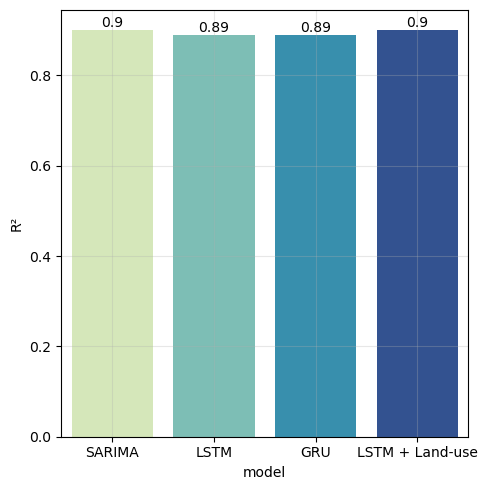

In [1012]:
plt.figure(figsize=(5,5))
ax = sns.barplot(x="model_name", y="value", hue="model_name", palette="YlGnBu", legend=False, data=overall_r2, errorbar=None)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("model")
plt.ylabel("R²")
plt.tight_layout()
ax.grid(True, alpha=0.3)
plt.savefig("./Images/performance/overall_r2.png", dpi=300, bbox_inches="tight")
plt.show()

In [1013]:
overall_error = overall_test.melt(
    id_vars=["model_name","data_split"],
    value_vars=["MAE", "RMSE"],
    var_name="metric",
    value_name="value"
)

In [1014]:
overall_error

,model_name,data_split,metric,value
0,SARIMA,Test,MAE,0.0474
1,LSTM,Test,MAE,0.0500
2,GRU,Test,MAE,0.0528
3,LSTM + Land-use,Test,MAE,0.0467
4,SARIMA,Test,RMSE,0.0698
5,LSTM,Test,RMSE,0.0705
6,GRU,Test,RMSE,0.0718
7,LSTM + Land-use,Test,RMSE,0.0668


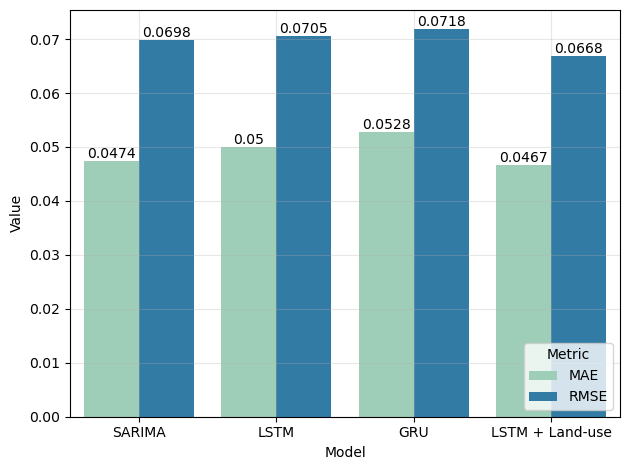

In [1046]:
ax = sns.barplot(x="model_name", y="value", hue="metric", palette="YlGnBu", data=overall_error, errorbar=None)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Model")
plt.ylabel("Value")
plt.legend(title="Metric", loc="lower right")
plt.tight_layout()
ax.grid(True, alpha=0.3)
plt.savefig("./Images/performance/overall_error.png", dpi=300, bbox_inches="tight")
plt.show()

In [1202]:
comparison = overall_error.pivot(columns="model_name", index="metric", values="value")

In [1203]:
comparison

model_name,GRU,LSTM,LSTM + Land-use,SARIMA
metric,,,,
MAE,0.0528,0.0500,0.0467,0.0474
RMSE,0.0718,0.0705,0.0668,0.0698


In [1215]:
gru_difference = comparison["SARIMA"] - comparison["GRU"]
lstm_difference = comparison["SARIMA"] - comparison["LSTM"]
gru_lstm_difference = comparison["GRU"] - comparison["LSTM"]
lstm_land_difference = comparison["LSTM"] - comparison["LSTM + Land-use"]

In [1205]:
gru_difference = comparison

metric
MAE    -0.0054
RMSE   -0.0020
dtype: float64

In [1206]:
lstm_difference

metric
MAE    -0.0026
RMSE   -0.0007
dtype: float64

In [1216]:
gru_lstm_difference

metric
MAE     0.0028
RMSE    0.0013
dtype: float64

In [1214]:
lstm_land_difference

metric
MAE     0.0033
RMSE    0.0037
dtype: float64

## Model generalization ability

In [1016]:
performance_r2 = df_performance[["model_name", "data_split", "R2"]]

In [1017]:
performance_r2

,model_name,data_split,R2
0,LSTM,Train,0.92
1,GRU,Train,0.92
2,LSTM + Land-use,Train,0.93
3,SARIMA,Validation,0.91
4,LSTM,Validation,0.88
5,GRU,Validation,0.88
6,LSTM + Land-use,Validation,0.90
7,SARIMA,Test,0.90
8,LSTM,Test,0.89
9,GRU,Test,0.89


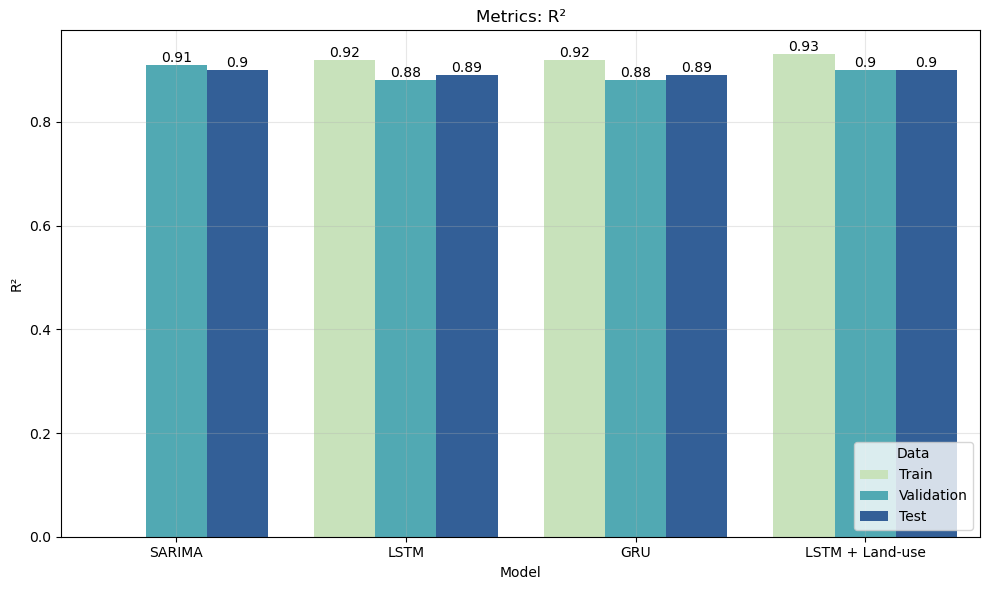

In [1114]:
plt.figure(figsize=(10,6))
model_order = ["SARIMA", "LSTM", "GRU", "LSTM + Land-use"]

ax = sns.barplot(
    data=performance_r2,
    x="model_name",
    y="R2",
    hue="data_split",
    order=model_order,
    palette="YlGnBu"
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Metrics: R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.legend(title="Data", loc="lower right")
plt.tight_layout()
ax.grid(True, alpha=0.3)
plt.savefig("./Images/performance/generalize_r2.png", dpi=300, bbox_inches="tight")
plt.show()

In [1019]:
performance_mae = df_performance[["model_name", "data_split", "MAE"]]

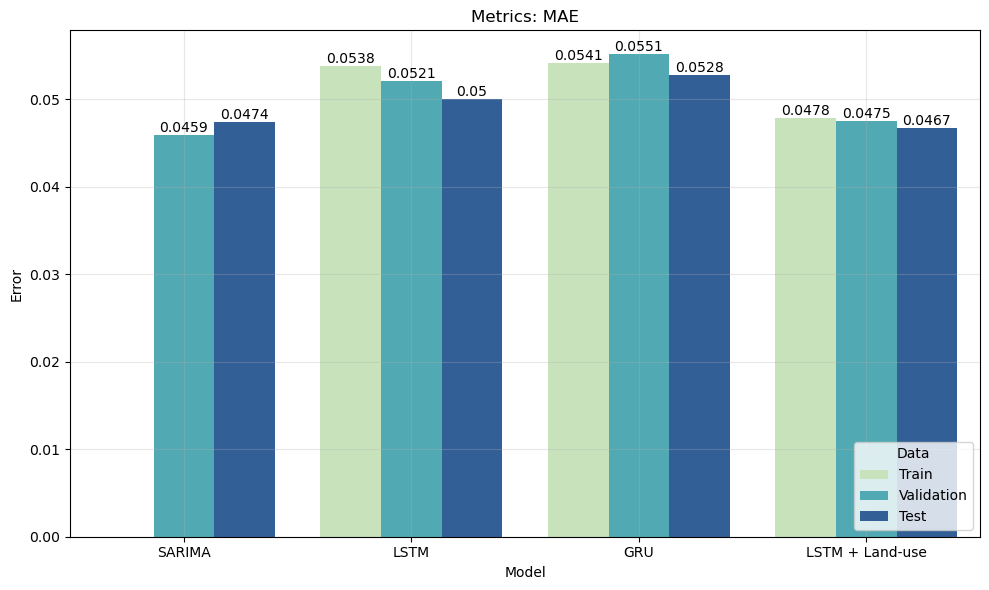

In [1115]:
plt.figure(figsize=(10,6))
model_order = ["SARIMA", "LSTM", "GRU", "LSTM + Land-use"]

ax = sns.barplot(
    data=performance_mae,
    x="model_name",
    y="MAE",
    hue="data_split",
    order=model_order,
    palette="YlGnBu"
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Metrics: MAE")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend(title="Data", loc="lower right")
plt.tight_layout()
ax.grid(True, alpha=0.3)
plt.savefig("./Images/performance/generalized_mae.png", dpi=300, bbox_inches="tight")
plt.show()

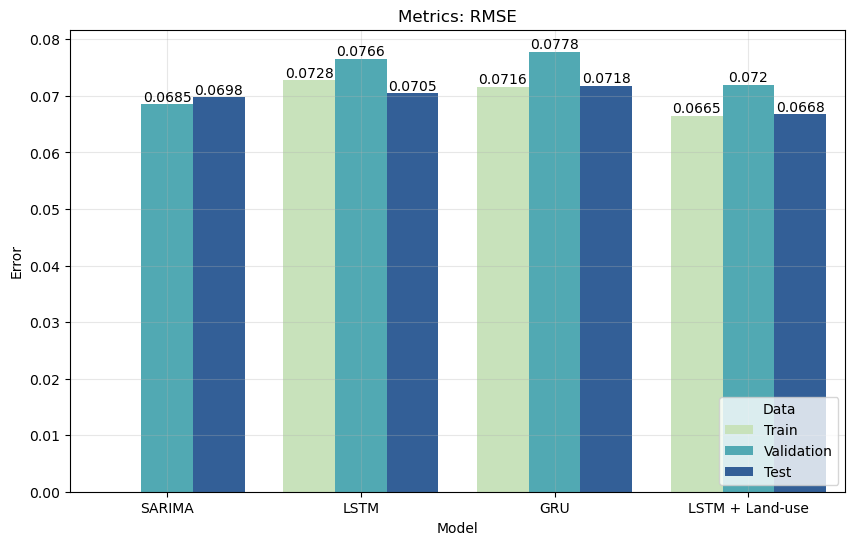

In [1116]:
performance_rmse = df_performance[["model_name", "data_split", "RMSE"]]
plt.figure(figsize=(10,6))
model_order = ["SARIMA", "LSTM", "GRU", "LSTM + Land-use"]

ax = sns.barplot(
    data=performance_rmse,
    x="model_name",
    y="RMSE",
    hue="data_split",
    order=model_order,
    palette="YlGnBu"
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Metrics: RMSE")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend(title="Data", loc="lower right")
#plt.tight_layout()
ax.grid(True, alpha=0.3)
plt.savefig("./Images/performance/generalized_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

#### Error analysis

In [1022]:
color_pallete = ["#9edae1","#345f97","#c8e2bb", "#e7efba"]

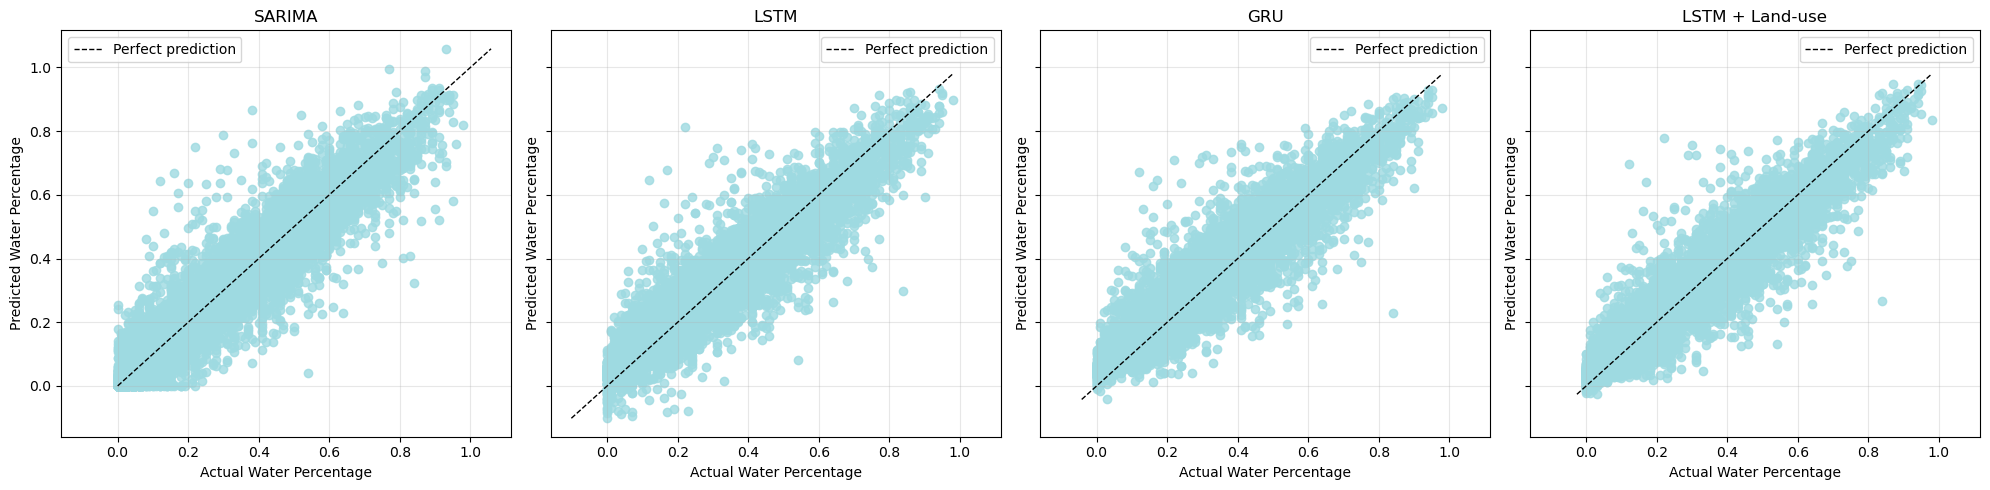

In [1117]:
fig, axes = plt.subplots(1, 4, figsize=(20,5), sharex=True, sharey=True)

plot_data = [
    ("SARIMA", sarima_test_predictions),
    ("LSTM", lstm_test_predictions),
    ("GRU", gru_test_predictions),
    ("LSTM + Land-use", lstm_land_test_predictions)
]

for ax, (model_name, df) in zip(axes, plot_data):
    actual = df["actual"]
    predicted = df["predicted"]

    ax.scatter(
        actual,
        predicted,
        alpha=0.8,
        color=color_pallete[0]
    )

    # Perfect prediction line
    min_value = min(actual.min(), predicted.min())
    max_value = max(actual.max(), predicted.max())

    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Perfect prediction"
    )

    ax.set_title(model_name)
    ax.set_xlabel("Actual Water Percentage")
    ax.set_ylabel("Predicted Water Percentage")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./Images/performance/model_error.png", dpi=300, bbox_inches="tight")
plt.show()

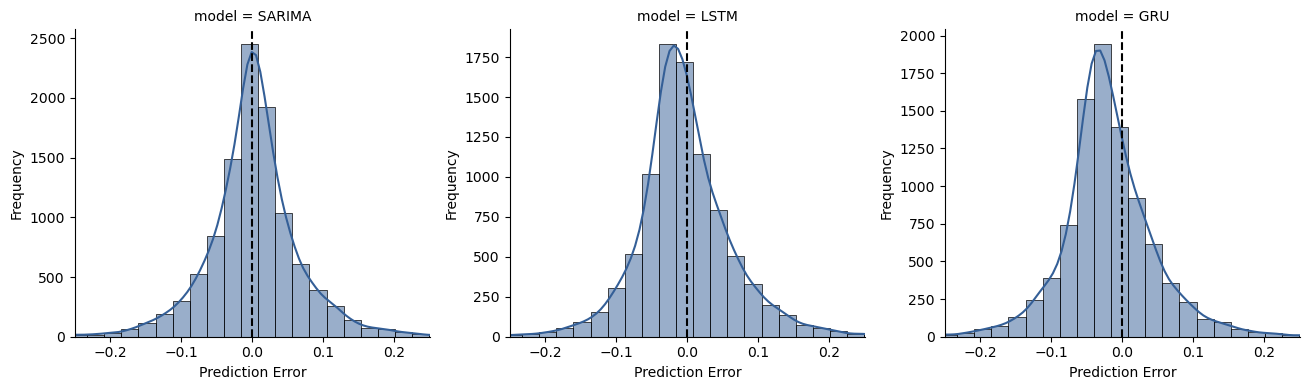

In [1024]:
sarima_test_predictions["model"] = "SARIMA"
lstm_test_predictions["model"] = "LSTM"
gru_test_predictions["model"] = "GRU"

error_df = pd.concat([
    sarima_test_predictions,
    lstm_test_predictions,
    gru_test_predictions
], ignore_index=True)

error_df["error"] = round(error_df["actual"] - error_df["predicted"],4)

g = sns.displot(
    data=error_df,
    x="error",
    col="model",
    bins=50,
    kde=True,
    height=4,
    aspect=1.1,
    color=color_pallete[1],
    facet_kws={"sharex": True, "sharey": False}
)

for ax in g.axes.flat:
    ax.axvline(0, linestyle="--", color="black")
    ax.set_xlim(-0.25, 0.25)
    ax.set_xlabel("Prediction Error")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Timeseries analysis

In [1025]:
sarima_test_predictions["date_time"] = pd.to_datetime(sarima_test_predictions["date_time"])
lstm_test_predictions["date_time"] = pd.to_datetime(lstm_test_predictions["date_time"])
gru_test_predictions["date_time"] = pd.to_datetime(gru_test_predictions["date_time"])
lstm_land_test_predictions["date_time"] = pd.to_datetime(lstm_land_test_predictions["date_time"])

In [1026]:
all_data = pd.read_csv("flood_land_data.csv")
all_data["date_time"] = pd.to_datetime(all_data["date_time"])

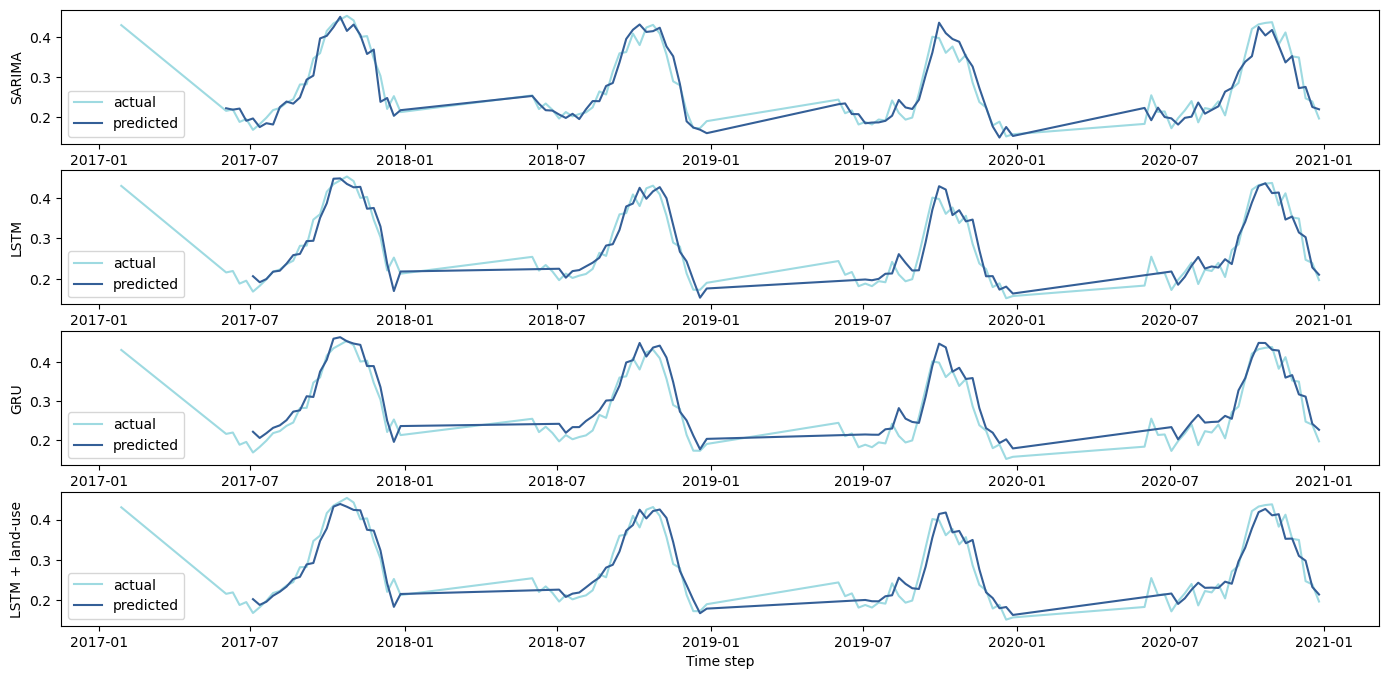

In [1118]:
plt.figure(figsize=(17, 8))

plt.subplot(411)
sns.lineplot(data=test, x="date_time", y="water_percentage", label="actual", color=color_pallete[0], errorbar=None)
sns.lineplot(data=sarima_test_predictions, x="date_time", y="predicted", color=color_pallete[1], label="predicted", errorbar=None)
plt.ylabel("SARIMA")
plt.legend(loc="lower left")

plt.subplot(412)
sns.lineplot(data=test, x="date_time", y="water_percentage", label="actual", color=color_pallete[0], errorbar=None)
sns.lineplot(data=lstm_test_predictions, x="date_time", y="predicted", color=color_pallete[1], label="predicted", errorbar=None)
plt.ylabel("LSTM")
plt.legend(loc="lower left")

plt.subplot(413)
sns.lineplot(data=test, x="date_time", y="water_percentage", label="actual", color=color_pallete[0], errorbar=None)
sns.lineplot(data=gru_test_predictions, x="date_time", y="predicted", label="predicted", color=color_pallete[1], errorbar=None)
plt.ylabel("GRU")
plt.legend(loc="lower left")

plt.subplot(414)
sns.lineplot(data=test, x="date_time", y="water_percentage", label="actual", color=color_pallete[0], errorbar=None)
sns.lineplot(data=lstm_land_test_predictions, x="date_time", y="predicted", label="predicted", color=color_pallete[1], errorbar=None)
plt.ylabel("LSTM + land-use")
plt.legend(loc="lower left")

plt.xlabel("Time step")
plt.savefig("./Images/performance/model_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

In [1089]:
def rmse_per_month(data, model_name):
    df = data.copy()
    error_per_month = []
    df["month"] = df["date_time"].dt.month
    for month, month_data in df.groupby("month"):
        y_true = month_data["actual"]
        y_pred = month_data["predicted"]
        rmse = root_mean_squared_error(y_true, y_pred)
        error_per_month.append({
            "month": month,
            "rmse": rmse,
            "model": model_name
        })
    return pd.DataFrame(error_per_month)

In [1090]:
sarima_rmse_per_month = rmse_per_month(sarima_test_predictions, "SARIMA")
lstm_rmse_per_month = rmse_per_month(lstm_test_predictions, "LSTM")
gru_rmse_per_month = rmse_per_month(gru_test_predictions, "GRU")
lstm_land_rmse_per_month = rmse_per_month(lstm_land_test_predictions, "LSTM + Land")

monthly_rmse_per_model = pd.concat(
    [sarima_rmse_per_month, lstm_rmse_per_month, gru_rmse_per_month, lstm_land_rmse_per_month],
    ignore_index=True
)

In [1091]:
monthly_rmse_per_model

,month,rmse,model
0,6,0.070483,SARIMA
1,7,0.047787,SARIMA
2,8,0.063374,SARIMA
3,9,0.068774,SARIMA
4,10,0.084859,SARIMA
5,11,0.081677,SARIMA
6,12,0.069135,SARIMA
7,7,0.051408,LSTM
8,8,0.068086,LSTM
9,9,0.071059,LSTM


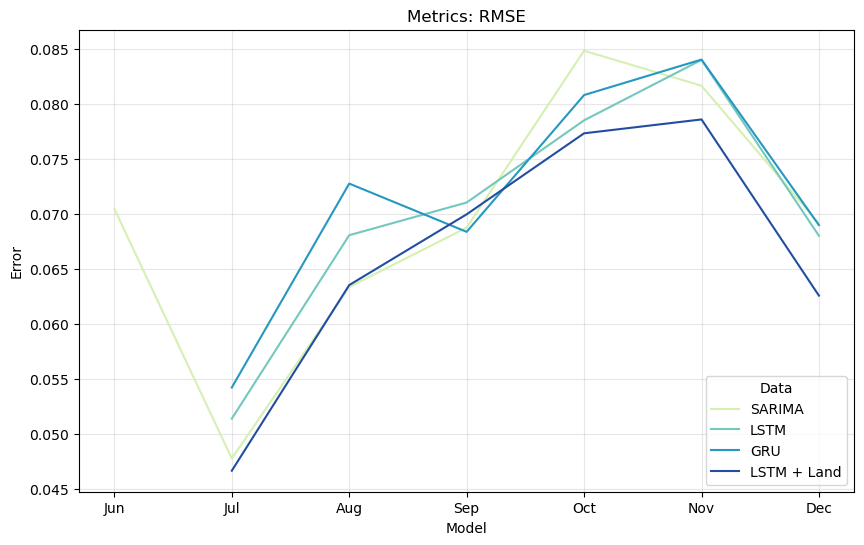

In [1119]:
plt.figure(figsize=(10,6))
month_order = ["Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

ax = sns.lineplot(
    data=monthly_rmse_per_model,
    x="month",
    y="rmse",
    hue="model",
    palette="YlGnBu"
)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Metrics: RMSE")
plt.xlabel("Model")
plt.xticks(ticks=range(6,13),labels=month_order)
plt.ylabel("Error")
plt.legend(title="Data", loc="lower right")
#plt.tight_layout()
ax.grid(True, alpha=0.3)
plt.savefig("./Images/performance/monthly_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

#### Spatial analysis

In [1033]:
def performance_per_grid(df):
    performance_per_grid = []
    
    for (x, y), grid_data in df.groupby(["x_coord", "y_coord"]):
        y_true = grid_data["actual"]
        y_pred = grid_data["predicted"]
        rmse = root_mean_squared_error(y_true, y_pred)
        performance_per_grid.append({
            "x_coord": x,
            "y_coord": y,
            "n_obs": len(grid_data),
            "rmse": rmse
        })
    return pd.DataFrame(performance_per_grid)

In [1034]:
def pivot_table_rmse(grid_performance):
    rmse_pivot = grid_performance.pivot_table(
        index="y_coord", 
        columns="x_coord", 
        values="rmse"
    )
    return rmse_pivot

In [1035]:
# Extract pivot table for rmse metric per model
sarima_performance_per_grid = performance_per_grid(sarima_test_predictions)
sarima_pivot_rmse = pivot_table_rmse(sarima_performance_per_grid)
lstm_performance_per_grid = performance_per_grid(lstm_test_predictions)
lstm_pivot_rmse = pivot_table_rmse(lstm_performance_per_grid)
gru_performance_per_grid = performance_per_grid(gru_test_predictions)
gru_pivot_rmse = pivot_table_rmse(gru_performance_per_grid)
lstm_land_performance_per_grid = performance_per_grid(lstm_land_test_predictions)
lstm_land_pivot_rmse = pivot_table_rmse(lstm_land_performance_per_grid)

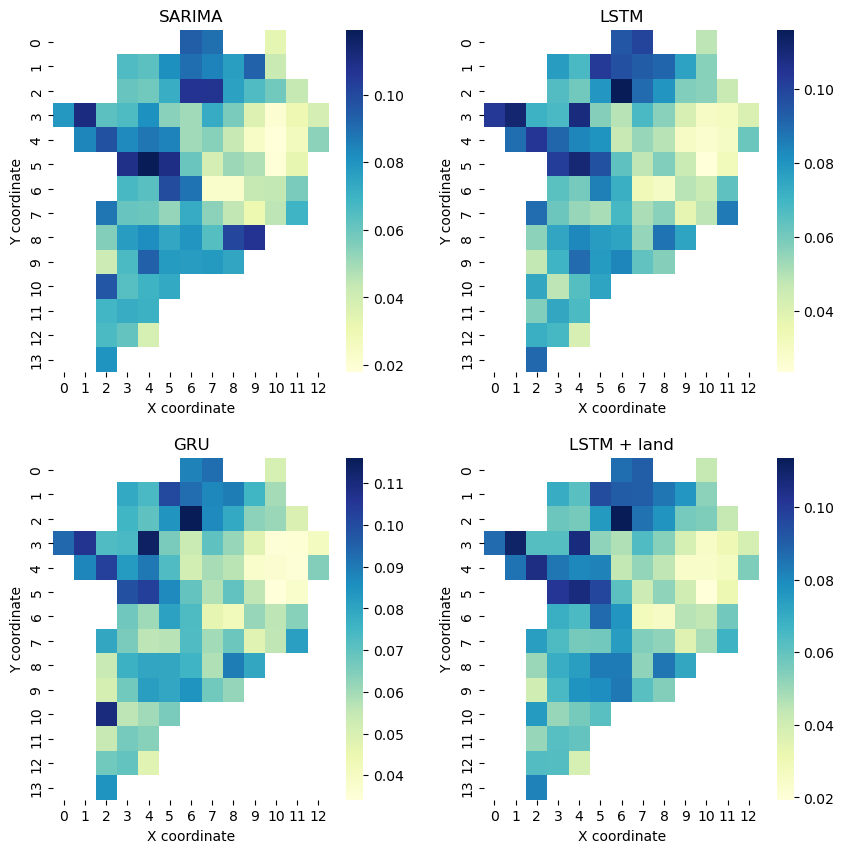

In [1122]:
# Visualize heatmap (RMSE)
plt.figure(figsize=(10,10))
plt.subplot(221), sns.heatmap(sarima_pivot_rmse, cmap="YlGnBu", fmt=".2f"), plt.title("SARIMA")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.subplot(222), sns.heatmap(lstm_pivot_rmse, cmap="YlGnBu", fmt=".2f"), plt.title("LSTM")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.subplot(223), sns.heatmap(gru_pivot_rmse, cmap="YlGnBu", fmt=".2f"), plt.title("GRU")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

plt.subplot(224), sns.heatmap(lstm_land_pivot_rmse, cmap="YlGnBu", fmt=".2f"), plt.title("LSTM + land")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")

#plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.25)
plt.savefig("./Images/performance/spatial_error.png", dpi=300, bbox_inches="tight")
plt.show()

## LSTM vs LSTM with exogenous

Error improvement

In [1038]:
lstm_land_performance_per_grid = performance_per_grid(lstm_land_test_predictions)
lstm_land_pivot_rmse = pivot_table_rmse(lstm_land_performance_per_grid)

In [1039]:
lstm_comparison = abs(lstm_pivot_rmse) - abs(lstm_land_pivot_rmse)

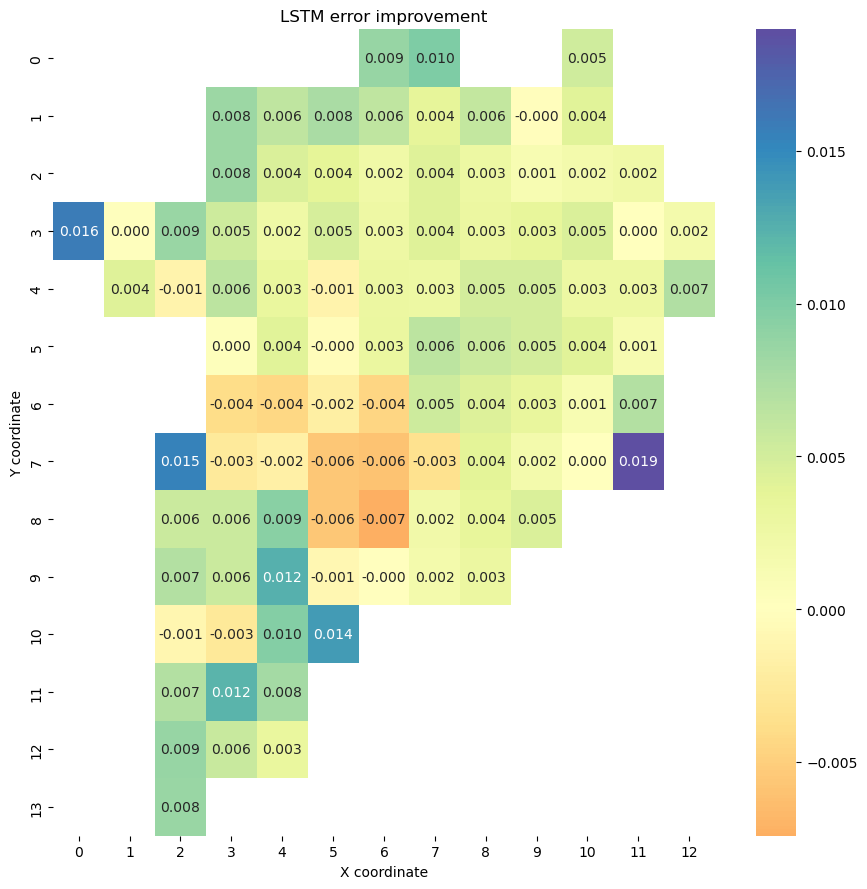

In [1040]:
# Visualize heatmap (RMSE)
plt.figure(figsize=(9,9))
sns.heatmap(lstm_comparison, cmap="Spectral", center=0, annot=True, fmt=".3f"), plt.title("LSTM error improvement")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.tight_layout()
plt.savefig("./Images/performance/question2_lstm_error.png", dpi=300, bbox_inches="tight")
plt.show()

In [1096]:
lstm_land_test_predictions["water_level"] = pd.qcut(
    lstm_land_test_predictions["actual"],
    q=3,
    labels=["Low", "Medium", "High"]
)

lstm_test_predictions["water_level"] = pd.qcut(
    lstm_test_predictions["actual"],
    q=3,
    labels=["Low", "Medium", "High"]
)

sarima_test_predictions["water_level"] = pd.qcut(
    sarima_test_predictions["actual"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [1097]:
def rmse_by_level(df, model):
    rmse_by_level = []
    for level in ["Low", "Medium", "High"]:
        subset = df[df["water_level"] == level]
        rmse = root_mean_squared_error(subset["actual"], subset["predicted"])
        rmse_by_level.append({
            "water_level": level,
            "model": model,
            "rmse": rmse
        })
    rmse_by_level = pd.DataFrame(rmse_by_level)
    return rmse_by_level

In [1098]:
lstm_by_level = rmse_by_level(lstm_test_predictions, "LSTM")
lstm_land_by_level = rmse_by_level(lstm_land_test_predictions, "LSTM + Land-use")
sarima_by_level = rmse_by_level(sarima_test_predictions, "SARIMA")

In [1099]:
rmse_comparison = pd.concat([lstm_by_level, lstm_land_by_level, sarima_by_level], ignore_index=True)

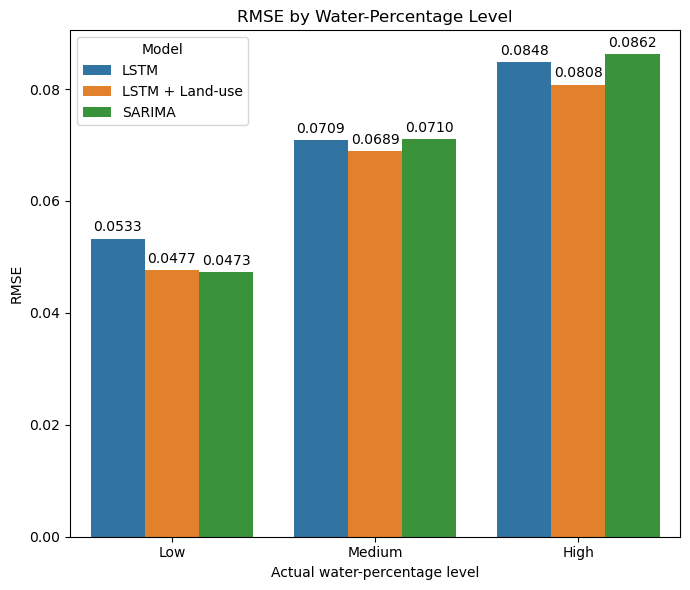

In [1100]:
plt.figure(figsize=(7, 6))

ax = sns.barplot(
    data=rmse_comparison,
    x="water_level",
    y="rmse",
    hue="model"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("RMSE by Water-Percentage Level")
plt.xlabel("Actual water-percentage level")
plt.ylabel("RMSE")
plt.legend(title="Model")
plt.tight_layout()
plt.show()